# Instructions

- This homework assignment is worth 47 points. 
- Please strive for clarity and organization.
- **AI Usage**:
   - AI use is strictly **prohibited** for conceptual exercises.
   - For applied (Python) exercises, you may only use AI for **debugging**. Do not use AI to generate answers.
- **Due Date: November 7, 2025, by 11:59 PM.**

# Exercise 1 

In this exercise, we will work with the `winemag-data-130k-v2.csv` data file. This file contains information about wine. The goal is to explore this data using the NLP techniques that we have learnt. For more information about the data file, see this [link](https://www.kaggle.com/datasets/zynicide/wine-reviews/data).

### Exercise 1(a) (2 points)

Load the following libraries as follows:

```
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Exercise 1(b) (2 points)

Read the `csv` file and create a data-frame called `wine_df`.

In [2]:
wine_df = pd.read_csv('winemag-data-130k-v2.csv')
wine_df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


### Exercise 1(c) (3 points)

Using the `string` library, remove all the punctuation of the `description` column and store the results in another column called `description_clean`.

In [3]:
import string

wine_df['description_clean'] = wine_df['description'].str.replace(f"[{string.punctuation}]", "", regex=True)
wine_df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,description_clean
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,Aromas include tropical fruit broom brimstone ...
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,This is ripe and fruity a wine that is smooth ...
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,Tart and snappy the flavors of lime flesh and ...
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,Pineapple rind lemon pith and orange blossom s...
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,Much like the regular bottling from 2012 this ...


### Exercise 1(d) (10 points)

Using the `nltk` library, remove stopwords, pronouns, and the following words: `drink`, `now`, `wine`, `flavor`, and `flavors` from `description_clean` and store in another column called `'description_clean_1'`. 

In [4]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stopwords = set(stopwords.words('english'))
pronouns = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves'])
others = set(['drink', 'now', 'wine', 'flavor', 'flavors'])

def clean_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stopwords and word not in pronouns and word not in others]
    return ' '.join(tokens)

wine_df['description_clean_1'] = wine_df['description_clean'].apply(clean_text)
wine_df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,description_clean,description_clean_1
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,Aromas include tropical fruit broom brimstone ...,aromas include tropical fruit broom brimstone ...
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,This is ripe and fruity a wine that is smooth ...,ripe fruity smooth still structured firm tanni...
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,Tart and snappy the flavors of lime flesh and ...,tart snappy lime flesh rind dominate green pin...
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,Pineapple rind lemon pith and orange blossom s...,pineapple rind lemon pith orange blossom start...
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,Much like the regular bottling from 2012 this ...,much like regular bottling 2012 comes across r...


### Exercise 1(e) (10 points)

Perform Lemmatization of `description_clean_1` and store the results in another column called `description_clean_2` in the `wine_df` data frame.

In [5]:
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# download NLTK resources
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Initialize the WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# funtion to get the part of speech tag for lemmatization
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words]
    return ' '.join(lemmatized_words)

wine_df['description_clean_2'] = wine_df['description_clean_1'].apply(lemmatize_text)
wine_df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,description_clean,description_clean_1,description_clean_2
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,Aromas include tropical fruit broom brimstone ...,aromas include tropical fruit broom brimstone ...,aroma include tropical fruit broom brimstone d...
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,This is ripe and fruity a wine that is smooth ...,ripe fruity smooth still structured firm tanni...,ripe fruity smooth still structure firm tannin...
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,Tart and snappy the flavors of lime flesh and ...,tart snappy lime flesh rind dominate green pin...,tart snappy lime flesh rind dominate green pin...
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,Pineapple rind lemon pith and orange blossom s...,pineapple rind lemon pith orange blossom start...,pineapple rind lemon pith orange blossom start...
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,Much like the regular bottling from 2012 this ...,much like regular bottling 2012 comes across r...,much like regular bottle 2012 come across rath...


### Exercise 1(f) (5 points)

Based on the results from part 1(g), we see digits in some of the text in `description_clean_2`. Remove all the digits from `description_clean_2` and store the results in another column `description_clean_3` in the `wine_df` data frame.

In [6]:
import re

# function to remove numbers
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

wine_df['description_clean_3'] = wine_df['description_clean_2'].apply(remove_numbers)
wine_df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,description_clean,description_clean_1,description_clean_2,description_clean_3
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,Aromas include tropical fruit broom brimstone ...,aromas include tropical fruit broom brimstone ...,aroma include tropical fruit broom brimstone d...,aroma include tropical fruit broom brimstone d...
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,This is ripe and fruity a wine that is smooth ...,ripe fruity smooth still structured firm tanni...,ripe fruity smooth still structure firm tannin...,ripe fruity smooth still structure firm tannin...
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,Tart and snappy the flavors of lime flesh and ...,tart snappy lime flesh rind dominate green pin...,tart snappy lime flesh rind dominate green pin...,tart snappy lime flesh rind dominate green pin...
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,Pineapple rind lemon pith and orange blossom s...,pineapple rind lemon pith orange blossom start...,pineapple rind lemon pith orange blossom start...,pineapple rind lemon pith orange blossom start...
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,Much like the regular bottling from 2012 this ...,much like regular bottling 2012 comes across r...,much like regular bottle 2012 come across rath...,much like regular bottle come across rather r...


### Exercise 1(g) (5 points)

Generate embeddings using the `BERT` model on `description_clean_3`.

In [7]:
from sentence_transformers import SentenceTransformer

print("loading BERT model...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded.")

# Generate BERT embeddings for the cleaned text
print("Generating BERT embeddings...")
bert_embeddings = bert_model.encode(wine_df['description_clean_3'].tolist(), show_progress_bar=True, batch_size=32)

print(f'BERT embeddings shape: {bert_embeddings.shape}')
print(f'each document is represented by a {bert_embeddings.shape[1]}-dimensional vector')

loading BERT model...
Model loaded.
Generating BERT embeddings...


Batches:   0%|          | 0/4062 [00:00<?, ?it/s]

BERT embeddings shape: (129971, 384)
each document is represented by a 384-dimensional vector


### Exercise 1(h) (5 points)

Compute and visualize the principal components of the bert embedding.

C:\Users\gmgma\AppData\Local\Temp\ipykernel_29180\678407370.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='coolwarm', alpha=0.7)


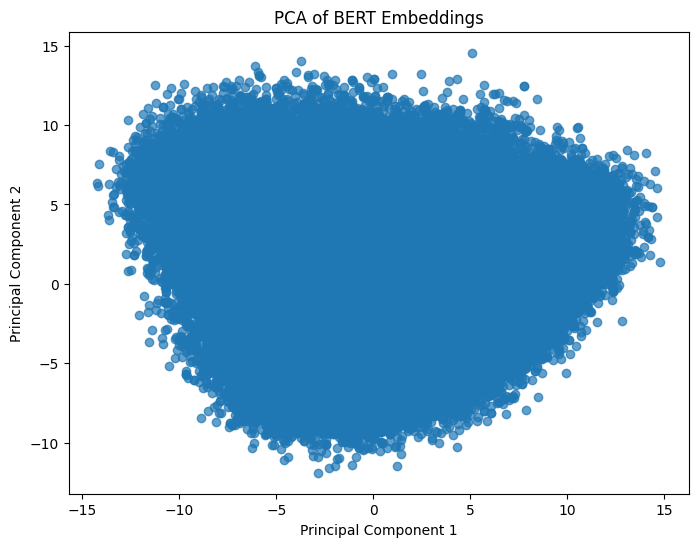

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Define the PCA model
pca = PCA()

# Standardize the embeddings
scaler = StandardScaler()
bert_embeddings_std = scaler.fit_transform(bert_embeddings)

# Fit PCA on standardized embeddings
X_pca = pca.fit_transform(bert_embeddings_std)

# Plotting pca results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='coolwarm', alpha=0.7)
plt.title('PCA of BERT Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### Exercise 1(i) (5 points)

Estimate the number of clusters on the bert embedding using silhouette, Calinski Harabasz, and Davies Bouldin scores. Consider 2 to 6 clusters.

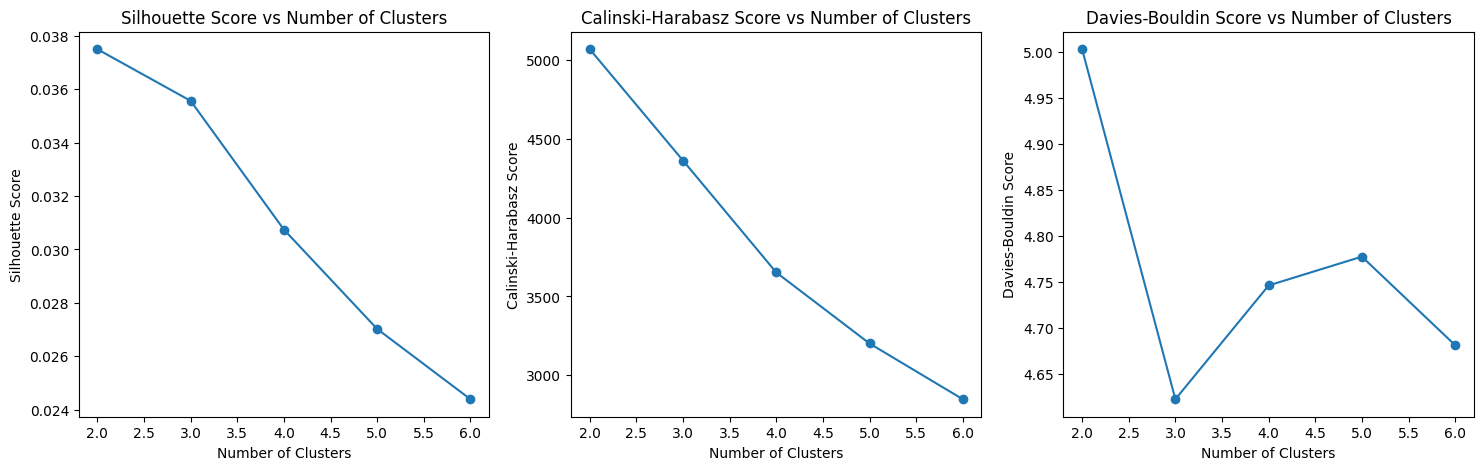

In [10]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans

silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

for n_clusters in range(2, 7):
    # Perform KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    cluster_labels = KMeans.fit_predict(kmeans, bert_embeddings_std)
    
    # Calculate clustering metrics
    silhouette_avg = silhouette_score(bert_embeddings_std, cluster_labels)
    calinski_harabasz_avg = calinski_harabasz_score(bert_embeddings_std, cluster_labels)
    davies_bouldin_avg = davies_bouldin_score(bert_embeddings_std, cluster_labels)
    
    # Store the scores
    silhouette_scores.append(silhouette_avg)
    calinski_harabasz_scores.append(calinski_harabasz_avg)
    davies_bouldin_scores.append(davies_bouldin_avg)
    
# Plot the clustering metrics
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(range(2, 7), silhouette_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.subplot(1, 3, 2)
plt.plot(range(2, 7), calinski_harabasz_scores, marker='o')
plt.title('Calinski-Harabasz Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Calinski-Harabasz Score')

plt.subplot(1, 3, 3)
plt.plot(range(2, 7), davies_bouldin_scores, marker='o')
plt.title('Davies-Bouldin Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')
plt.show()

I would use 2 clusters because two of the three charts peak at 2 clusters